### Week 10 Follow Along Coding Practice: Time Series
Owen Randolph, DSCI-590: Applied Data Science, 10/28/2024

In [3]:
from pandas import read_csv
from matplotlib import pyplot as plt

Date
1981-01-01    20.7
1981-01-02    17.9
1981-01-03    18.8
1981-01-04    14.6
1981-01-05    15.8
Name: Temp, dtype: float64


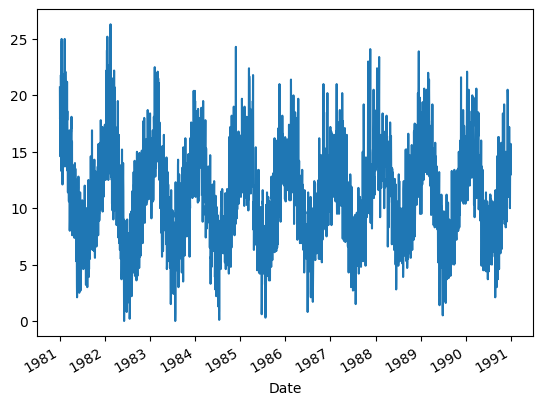

In [4]:
# Use first column to create a Series
series = read_csv('daily-minimum-temperatures.csv', header=0, index_col=0, parse_dates=[0]).iloc[:, 0]

print(series.head())
series.plot()
plt.show()

In [5]:
print(series.describe())

count    3650.000000
mean       11.177753
std         4.071837
min         0.000000
25%         8.300000
50%        11.000000
75%        14.000000
max        26.300000
Name: Temp, dtype: float64


#### Annual Data Comparison
To plot annual data comparison, we wil create a dataframe with values grouped by years

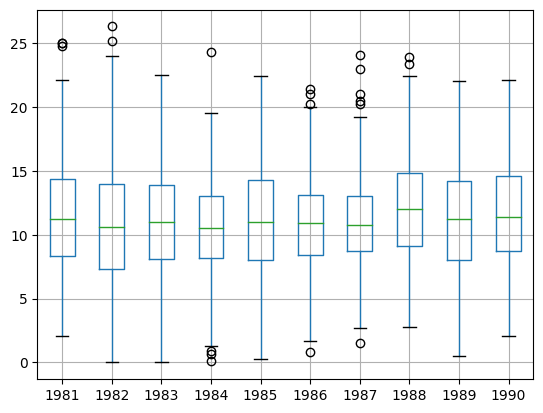

In [6]:
# Create box plots of temperature data based on years
from pandas import Grouper
from pandas import DataFrame as df
groups = series.groupby(Grouper(freq = 'YE'))
years = df()
for name, group in groups:
    years[name.year] = group.values
years.boxplot()
plt.show()

##### Monthly Comparison

<ipython-input-7-63e5f1988866>:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  ts = one_year.groupby(Grouper(freq='M'))


Date
1990-01-31    15.577419
1990-02-28    15.417857
1990-03-31    14.835484
1990-04-30    13.433333
1990-05-31     9.748387
1990-06-30     7.720000
1990-07-31     8.183871
1990-08-31     7.825806
1990-09-30     9.166667
1990-10-31    11.345161
1990-11-30    12.656667
1990-12-31    14.367742
Freq: ME, Name: Temp, dtype: float64


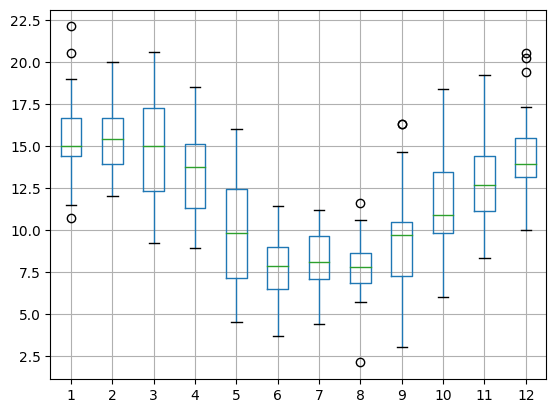

In [7]:
from pandas import concat
one_year = series['1990']
ts = one_year.groupby(Grouper(freq='M'))
print(ts.mean())

months = concat([df(t[1].values) for t in ts], axis=1)
months = df(months)
months.columns = range(1,13)
months.boxplot()
plt.show()

### Decomposition

We will use the airline dataset, describing the total number of passengers over time, decomposing seasonally

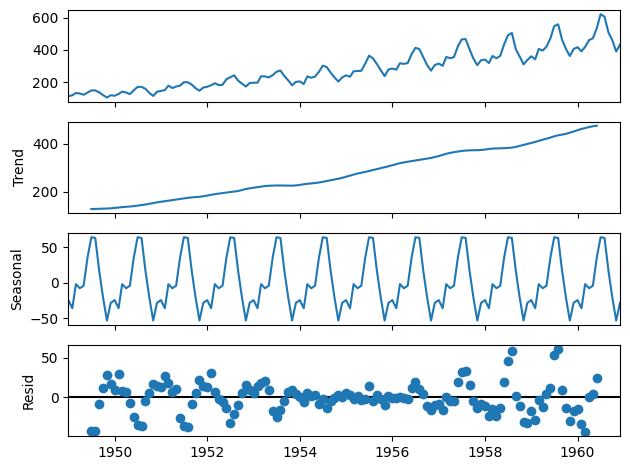

In [8]:
# An additive data model shows the effects of individual factors  differentiated and added together to model the data
from statsmodels.tsa.seasonal import seasonal_decompose
series = read_csv('airline-passengers.csv', header=0, index_col=0, parse_dates=True)
result = seasonal_decompose(series, model='additive')
result.plot()
plt.show()

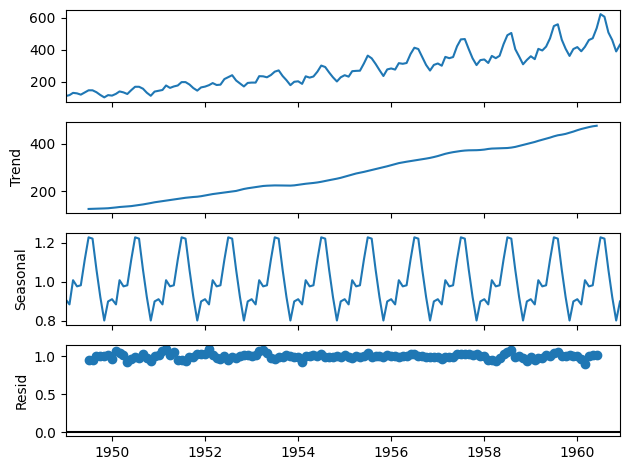

In [9]:
# The multiplicative model assumes that as the data increase, so does the seasonal pattern. Most time series plots exhibit such a pattern.
# In this model, the trend and seasonal components are multiplied and then added to the error component.
from statsmodels.tsa.seasonal import seasonal_decompose
series = read_csv('airline-passengers.csv', header=0, index_col=0, parse_dates=True)
result = seasonal_decompose(series, model='multiplicative')
result.plot()
plt.show()

#### Autoregression Model

An autoregression model is a linear regression model that uses lagged variables as input variables.

<ipython-input-10-bdb657d10b25>:16: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print('predicted=%f, expected=%f' % (predictions[i], test[i]))


predicted=11.871275, expected=12.900000
predicted=13.053794, expected=14.600000
predicted=13.532591, expected=14.000000
predicted=13.243126, expected=13.600000
predicted=13.091438, expected=13.500000
predicted=13.146989, expected=15.700000
predicted=13.176153, expected=13.000000
Test RMSE: 1.225


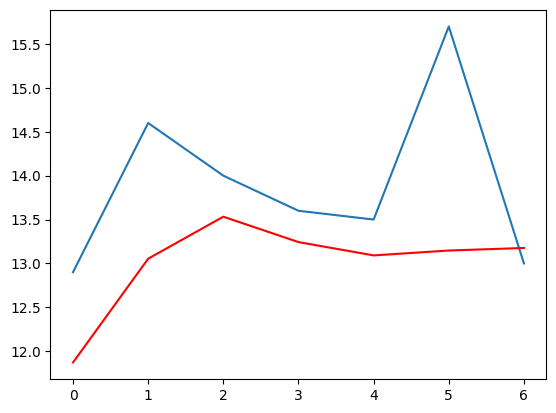

In [10]:
from statsmodels.tsa.ar_model import AutoReg
from sklearn.metrics import mean_squared_error
from math import sqrt

series = read_csv('daily-minimum-temperatures.csv', header=0, index_col=0, parse_dates=True)
# Split dataset into training and testing
X = series.values
train, test = X[1:len(X)-7], X[len(X)-7:]
# Train autoregression
model = AutoReg(train, lags=29)
model_fit = model.fit()

# Make predictions
predictions = model_fit.predict(start=len(train), end=len(train)+len(test)-1, dynamic=False)
for i in range(len(predictions)):
  print('predicted=%f, expected=%f' % (predictions[i], test[i]))
rmse = sqrt(mean_squared_error(test, predictions))
print('Test RMSE: %.3f' % rmse)
# Plot results
plt.plot(test)
plt.plot(predictions, color='red')
plt.show()

The forecast deviation is about 1 degree C off each day and has a large deviation on Day 5.

## Chapter 12: TS Decomposition

In [21]:
# Example of decomposing a time series
from random import randrange
from statsmodels.tsa.seasonal import seasonal_decompose
series = [i + randrange(10) for i in range(1, 100)]
result = seasonal_decompose(series, model='additive', period=12)
print(result.trend)
print(result.seasonal)
print(result.resid)
print(result.observed)

[        nan         nan         nan         nan         nan         nan
 11.95833333 12.91666667 13.75       14.75       15.83333333 16.5
 17.16666667 18.33333333 19.58333333 20.66666667 21.79166667 22.79166667
 23.29166667 24.         24.79166667 25.33333333 26.08333333 27.29166667
 28.625      29.625      30.70833333 31.5        32.29166667 33.58333333
 34.79166667 36.04166667 37.54166667 38.79166667 39.75       40.41666667
 41.16666667 42.16666667 43.125      44.45833333 45.83333333 46.625
 47.45833333 48.66666667 49.66666667 50.95833333 52.125      53.08333333
 54.20833333 55.375      56.58333333 57.66666667 58.58333333 59.41666667
 60.5        61.5        62.58333333 63.625      64.625      65.625
 66.375      67.33333333 68.08333333 68.54166667 69.25       70.45833333
 71.5        72.25       73.04166667 73.79166667 74.91666667 76.125
 77.20833333 78.16666667 79.04166667 79.875      80.79166667 81.625
 82.5        83.33333333 84.29166667 85.45833333 86.375      87.33333333
 88.5

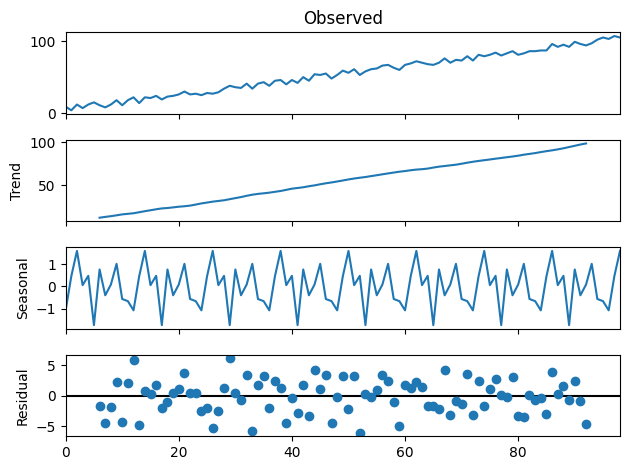

In [23]:
# Example of plotting a decomposed time series
from statsmodels.tsa.seasonal import seasonal_decompose
from matplotlib import pyplot
series
result
result.plot()
pyplot.show()

#### Additive Decomposition


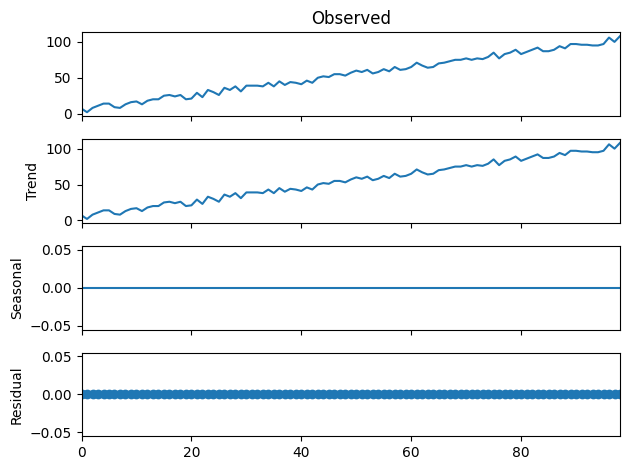

In [24]:
#  Example of an additive time series with parameter period=1, meaningthe frequency of observations = 1
series = [i + randrange(10) for i in range(1, 100)]
result = seasonal_decompose(series, model='additive', period=1)
result.plot()
pyplot.show()

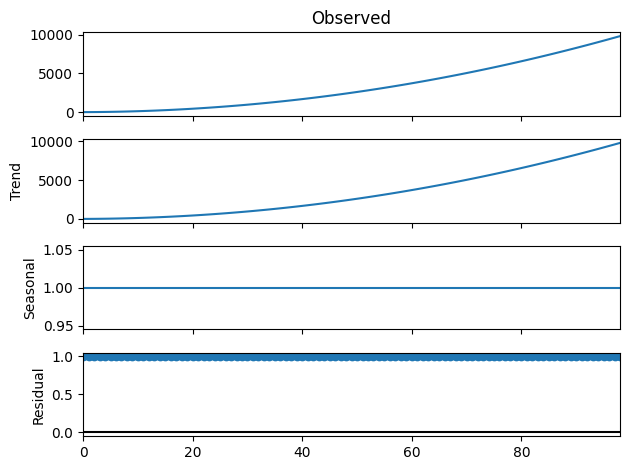

In [25]:
# Multiplicative decompose a contrived multiplicative time series
series = [i**2.0 for i in range(1, 100)]
result = seasonal_decompose(series, model='multiplicative', period=1)
result.plot()
pyplot.show()

#### Airline Passengers Dataset


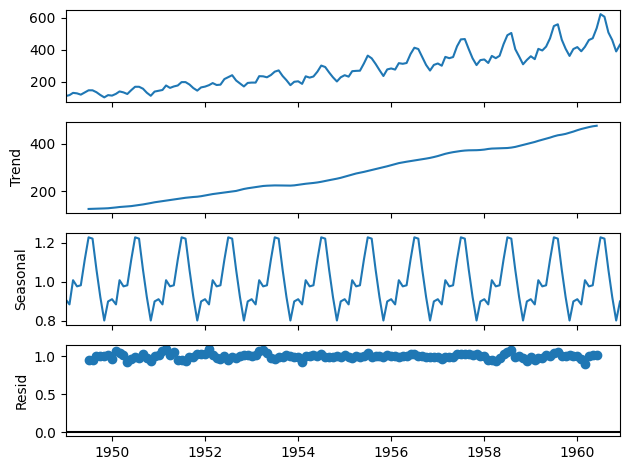

In [26]:
series = read_csv('airline-passengers.csv', header=0, index_col=0, parse_dates=True)
result = seasonal_decompose(series, model='multiplicative')
result.plot()
pyplot.show()